# Pronóstico de cultivos de coca 2025 por municipio y total nacional

**Objetivo:** estimar cuántas hectáreas de coca habrá en 2025, en cada municipio y en todo el país,
comparando cuatro métodos de pronóstico y quedándonos con el que mejor ha funcionado en el pasado.

**Fuente:** *Detección de Cultivos de Coca (hectáreas)* – SIMCI/Datos Abiertos (archivo del 31/08/2026),
el mismo que se usa para construir `fact_cultivos_raw` en el notebook de limpieza. Cubre **2001 a 2024**.

### Ruta del análisis
1. **Cargar los datos** y construir `fact_cultivos_raw` (con una corrección importante para el año 2020).
2. **Mirar la historia** del total nacional.
3. **Presentar los 4 modelos**: regresión lineal, regresión polinómica, Holt y ARIMA.
4. **Ponerlos a prueba en el pasado** (*backtesting*): pronosticar años que ya conocemos y medir el error.
5. **Total nacional**: elegir el mejor modelo y la mejor ventana (3, 5 o 10 años) y pronosticar 2025.
6. **Municipios**: repetir la prueba para cada municipio con coca reciente y pronosticar 2025.
7. **Limitaciones** y conclusiones.

> 💡 **Cómo ejecutarlo en Colab:** sube este notebook, ajusta `RUTA_COCA` en la celda de configuración
> para que apunte al CSV en tu Drive y ejecuta todas las celdas (*Entorno de ejecución → Ejecutar todas*).

## 0. Configuración

Importamos las librerías y definimos rutas, parámetros y colores. Si trabajas en Colab,
cambia `RUTA_COCA` por la ruta del archivo en tu Drive (la misma que usa el notebook de limpieza).

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.holtwinters import Holt
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")  # statsmodels avisa mucho con series cortas; no afecta los resultados

# --- Rutas ---------------------------------------------------------------------------
# En Colab: RUTA_COCA = "/content/drive/MyDrive/Proyecto_Policia/Datos/Detección_de_Cultivos_de_Coca_(hectáreas)_20260831.csv"
RUTA_COCA = Path("data/Deteccion_Cultivos_Coca_hectareas_20260831.csv")
CARPETA_RESULTADOS = Path("resultados")
CARPETA_RESULTADOS.mkdir(exist_ok=True)

# --- Parámetros del análisis ------------------------------------------------------------
VENTANAS = [3, 5, 10]                    # años de historia que ve cada modelo
ANIOS_PRUEBA = list(range(2019, 2025))   # años "del pasado" que usamos para medir el error (2019-2024)
ANIO_PRONOSTICO = 2025
TOP_MUNICIPIOS = 20                      # municipios que se muestran en detalle

# --- Nombres y colores de los modelos (paleta apta para daltonismo) ------------------------
MODELOS_NOMBRE = {
    "lineal": "Regresión lineal",
    "polinomica": "Regresión polinómica",
    "holt": "Holt",
    "arima": "ARIMA",
    "ingenuo": "Ingenuo (referencia)",
}
COLORES = {
    "lineal": "#2a78d6",      # azul
    "polinomica": "#eb6834",  # naranja
    "holt": "#1baf7a",        # verde agua
    "arima": "#eda100",       # amarillo
    "ingenuo": "#8a8985",     # gris: sólo referencia
    "real": "#0b0b0b",        # datos observados
}

# --- Estilo de gráficos: marcas finas y ejes discretos ----------------------------------
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#b5b4ae",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "lines.linewidth": 2, "font.size": 10,
    "legend.frameon": False,
})


def formato_miles(x, pos=None):
    """Formatea números al estilo colombiano: 261.386"""
    return f"{x:,.0f}".replace(",", ".")


EJE_MILES = mticker.FuncFormatter(formato_miles)
print("✅ Configuración lista")

✅ Configuración lista


## 1. Cargar los datos y construir `fact_cultivos_raw`

El archivo viene en formato **ancho**: una fila por municipio y una columna por año.
Lo pasamos a formato **largo** (una fila por municipio-año), igual que en el notebook de limpieza.

### ⚠️ Dos ajustes respecto al notebook de limpieza
1. **Años:** allá se cargan sólo 2019-2025. Para probar la ventana de **10 años** (y medir su error en
   años pasados) necesitamos toda la historia disponible, **2001-2024**. (La columna 2025 aún no existe
   en el archivo: justamente es lo que vamos a pronosticar.)
2. **Formato de números del año 2020:** esa columna viene con formato europeo (`8.832,92`) mientras
   las demás usan punto decimal (`8832.92`). La función `parsear_hectareas` original convierte
   `"8.832,92"` en `"8.832.92"`, falla y devuelve **0**. Resultado: **todos los municipios con más de
   1.000 ha en 2020 quedan en cero**. Aquí se corrige: si el texto tiene coma, el punto es separador
   de miles y la coma es el decimal.

In [2]:
def parsear_hectareas_original(valor):
    """Copia de la función del notebook de limpieza (sólo para mostrar el problema)."""
    if pd.isna(valor) or str(valor).strip() == "":
        return 0.0
    val_str = str(valor).strip()
    if val_str.count(".") > 1:
        partes = val_str.split(".")
        val_str = "".join(partes[:-1]) + "." + partes[-1]
    val_str = val_str.replace(",", ".")
    try:
        return float(val_str)
    except ValueError:
        return 0.0


def parsear_hectareas(valor):
    """Versión corregida. Acepta '8832.92' y también '8.832,92' (formato europeo del año 2020)."""
    if pd.isna(valor) or str(valor).strip() == "":
        return 0.0                                   # celda vacía = no se detectó coca
    texto = str(valor).strip()
    if "," in texto:                                 # formato europeo: 8.832,92
        texto = texto.replace(".", "").replace(",", ".")
    return float(texto)


# 1. Leer el archivo tal cual (todo como texto para no perder ceros a la izquierda)
df_coca_file = pd.read_csv(RUTA_COCA, sep=",", encoding="utf-8", dtype=str)
df_coca_file.columns = df_coca_file.columns.str.strip().str.upper()
df_coca_file["cod_municipio"] = df_coca_file["CODMPIO"].str.zfill(5)
columnas_anio = sorted(c for c in df_coca_file.columns if c.isdigit())

# 2. Pasar de formato ancho a largo: una fila por municipio y año
fact_cultivos_raw = df_coca_file.melt(
    id_vars=["cod_municipio", "MUNICIPIO", "DEPARTAMENTO"], value_vars=columnas_anio,
    var_name="anio", value_name="valor_texto",
)
fact_cultivos_raw["anio"] = fact_cultivos_raw["anio"].astype(int)
fact_cultivos_raw["hectareas_coca"] = fact_cultivos_raw["valor_texto"].apply(parsear_hectareas)

# 3. Tabla auxiliar con nombre y departamento de cada municipio
dim_municipio = (df_coca_file[["cod_municipio", "MUNICIPIO", "DEPARTAMENTO"]]
                 .rename(columns={"MUNICIPIO": "municipio", "DEPARTAMENTO": "departamento"})
                 .set_index("cod_municipio"))
dim_municipio["municipio"] = dim_municipio["municipio"].str.replace(r"\s*\(.*\)", "", regex=True).str.title()
dim_municipio["departamento"] = dim_municipio["departamento"].str.title()

fact_cultivos_raw = fact_cultivos_raw[["cod_municipio", "anio", "hectareas_coca"]]
print(f"✅ fact_cultivos_raw: {len(fact_cultivos_raw):,} filas | {fact_cultivos_raw['cod_municipio'].nunique()} municipios | "
      f"años {fact_cultivos_raw['anio'].min()}-{fact_cultivos_raw['anio'].max()}")

# 4. ¿Cuánto cambia el 2020 con la corrección?
total_2020_original = df_coca_file["2020"].apply(parsear_hectareas_original).sum()
total_2020_corregido = df_coca_file["2020"].apply(parsear_hectareas).sum()
print(f"\nTotal nacional 2020 con la función original : {formato_miles(total_2020_original)} ha")
print(f"Total nacional 2020 con la función corregida: {formato_miles(total_2020_corregido)} ha")
print(f"→ la función original perdía {formato_miles(total_2020_corregido - total_2020_original)} ha "
      f"({(1 - total_2020_original / total_2020_corregido):.0%} del total de ese año)")
fact_cultivos_raw.head()

✅ fact_cultivos_raw: 7,656 filas | 319 municipios | años 2001-2024

Total nacional 2020 con la función original : 27.282 ha
Total nacional 2020 con la función corregida: 142.784 ha
→ la función original perdía 115.502 ha (81% del total de ese año)


,cod_municipio,anio,hectareas_coca
0,91263,2001,191.82
1,91405,2001,65.00
2,91407,2001,0.00
3,91430,2001,0.00
4,91460,2001,6.00


Ahora organizamos los datos como una **tabla de series de tiempo**: filas = años, columnas = municipios.
Sumando todas las columnas obtenemos el **total nacional** de cada año.

In [3]:
panel = fact_cultivos_raw.pivot_table(index="anio", columns="cod_municipio",
                                      values="hectareas_coca", aggfunc="sum").fillna(0)
total_nacional = panel.sum(axis=1)

print(f"Tabla de series: {panel.shape[0]} años × {panel.shape[1]} municipios")
pd.DataFrame({"Hectáreas de coca (total nacional)": total_nacional.map(formato_miles)}).T

Tabla de series: 24 años × 319 municipios


anio,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Hectáreas de coca (total nacional),136.918,102.071,86.332,80.348,85.750,77.870,98.899,80.953,68.027,61.811,...,96.085,146.140,171.495,169.018,154.476,142.784,204.257,230.028,252.572,261.386


## 2. ¿Cómo se ha comportado la coca en Colombia?

Antes de pronosticar hay que **mirar la serie**. Un buen pronóstico depende de entender si la tendencia es estable
o si ha cambiado de dirección.

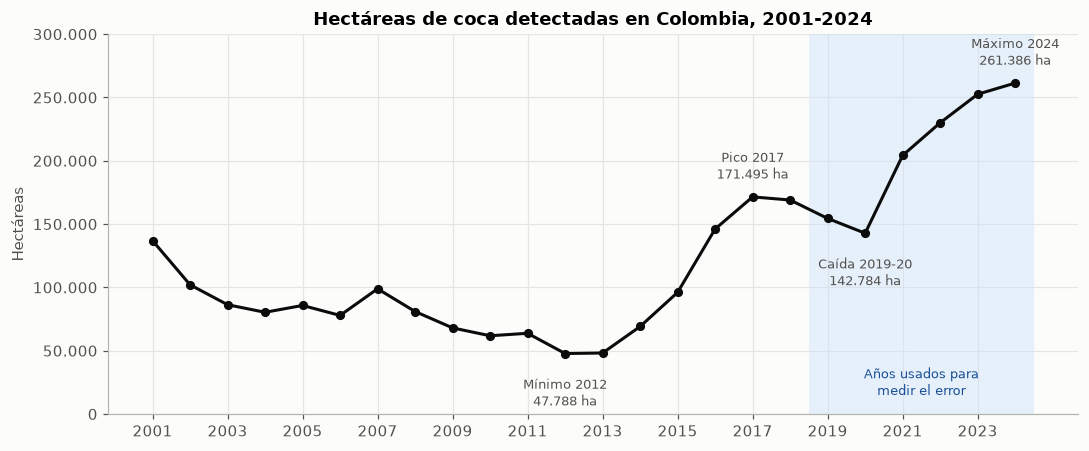

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(total_nacional.index, total_nacional.values, color=COLORES["real"], marker="o", markersize=5)
ax.yaxis.set_major_formatter(EJE_MILES)
ax.set_title("Hectáreas de coca detectadas en Colombia, 2001-2024")
ax.set_ylabel("Hectáreas")
ax.set_xticks(range(2001, 2025, 2))
ax.set_ylim(0, 300000)

# Anotaciones de los cambios de tendencia
for anio, texto in [(2012, "Mínimo 2012"), (2017, "Pico 2017"), (2020, "Caída 2019-20"), (2024, "Máximo 2024")]:
    ax.annotate(f"{texto}\n{formato_miles(total_nacional[anio])} ha", (anio, total_nacional[anio]),
                textcoords="offset points", xytext=(0, -34 if anio in (2012, 2020) else 12), ha="center",
                fontsize=8.5, color="#52514e")
ax.axvspan(2018.5, 2024.5, color="#cde2fb", alpha=0.45, lw=0)
ax.text(2021.5, 15000, "Años usados para\nmedir el error", ha="center", fontsize=8.5, color="#184f95")
plt.tight_layout()
plt.savefig(CARPETA_RESULTADOS / "01_serie_nacional.png")
plt.show()

**Lo que vemos:** la serie **no es una línea recta**. Cae de 2001 a 2012, se dispara entre 2013 y 2017,
baja un poco en 2019-2020 y vuelve a subir con fuerza hasta el máximo histórico de 2024.

Esto ya nos anticipa algo: un modelo que mire **10 años** verá sobre todo la fuerte subida desde 2014;
uno que mire **3 años** sólo verá la subida reciente. Qué ventana funciona mejor lo decide la prueba del paso 4.

## 3. Los cuatro modelos, en palabras sencillas

Cada modelo recibe los últimos *N* años (la **ventana**: 3, 5 o 10) y devuelve una cifra para el año siguiente.

| Modelo | Idea en una frase | Cuándo funciona bien |
|---|---|---|
| **Regresión lineal** | Traza la recta que mejor pasa por los puntos y la prolonga un año. | Cuando la serie sube o baja a ritmo constante. |
| **Regresión polinómica** (grado 2) | Igual, pero con una **curva** (parábola) en lugar de una recta. | Cuando la serie se acelera o se frena. Es arriesgada: una curva puede "dispararse" al prolongarla. |
| **Holt** (suavizado exponencial) | Sigue el **nivel** y la **tendencia** actuales, dando más peso a los años recientes. | Cuando la tendencia va cambiando poco a poco. |
| **ARIMA** | Modela cómo **cada año se parece al anterior** (y a sus cambios), con una deriva promedio. | Series con cierta "memoria"; necesita más datos que los otros. |
| *Ingenuo (referencia)* | "El año que viene será igual a este". | No es uno de los modelos pedidos: sirve de **vara de medir**. Si un modelo no le gana al ingenuo, no aporta. |

**Detalles técnicos (para quien los quiera):**
- La polinómica usa grado 2. Con 3 años la parábola pasa **exactamente** por los 3 puntos, así que no "suaviza" nada.
- Holt usa tendencia aditiva con parámetros estimados. Con sólo 3 años, el ajuste óptimo termina siendo
  prácticamente **la misma recta** de la regresión lineal (lo verás en los resultados).
- ARIMA prueba los órdenes (0,1,0), (1,1,0) y (0,1,1) con deriva y se queda con el de menor AIC.
  Con menos de 6 años sólo es posible el (0,1,0) con deriva: "el último valor + el crecimiento promedio".
- Ninguna hectárea puede ser negativa: si un modelo da un número menor que 0, se deja en 0.

In [5]:
def modelo_lineal(y):
    """Recta de mínimos cuadrados prolongada un año."""
    x = np.arange(len(y))
    pendiente, intercepto = np.polyfit(x, y, 1)
    return intercepto + pendiente * len(y)


def modelo_polinomico(y, grado=2):
    """Parábola de mínimos cuadrados prolongada un año."""
    x = np.arange(len(y))
    return np.polyval(np.polyfit(x, y, grado), len(y))


def modelo_holt(y):
    """Suavizado exponencial de Holt (nivel + tendencia)."""
    try:
        ajuste = Holt(y, initialization_method="estimated").fit()
        return float(ajuste.forecast(1)[0])
    except Exception:
        return y[-1] + (y[-1] - y[-2])   # respaldo: último valor + último cambio


def modelo_arima(y):
    """ARIMA con deriva; elige el orden con menor AIC entre unos pocos candidatos."""
    if np.allclose(y, y[0]):           # serie constante (p. ej. todo ceros): no hay nada que modelar
        return float(y[-1])
    ordenes = [(0, 1, 0)] if len(y) < 6 else [(0, 1, 0), (1, 1, 0), (0, 1, 1)]
    mejor = None
    for orden in ordenes:
        try:
            ajuste = ARIMA(y, order=orden, trend="t").fit()
            if mejor is None or ajuste.aic < mejor.aic:
                mejor = ajuste
        except Exception:
            continue
    return float(mejor.forecast(1)[0]) if mejor is not None else float(y[-1])


def modelo_ingenuo(y):
    """Referencia: el próximo año igual al último."""
    return float(y[-1])


MODELOS = {
    "lineal": modelo_lineal,
    "polinomica": modelo_polinomico,
    "holt": modelo_holt,
    "arima": modelo_arima,
    "ingenuo": modelo_ingenuo,
}


def pronosticar(serie, anio_objetivo, modelo, ventana):
    """Pronostica `anio_objetivo` usando sólo los `ventana` años inmediatamente anteriores."""
    historia = serie.loc[anio_objetivo - ventana: anio_objetivo - 1].to_numpy(dtype=float)
    return max(0.0, MODELOS[modelo](historia))   # no existen hectáreas negativas


print("✅ Modelos definidos:", ", ".join(MODELOS_NOMBRE[m] for m in MODELOS))

✅ Modelos definidos: Regresión lineal, Regresión polinómica, Holt, ARIMA, Ingenuo (referencia)


## 4. ¿Cómo sabemos cuál modelo es mejor? La "prueba en el pasado" (*backtesting*)

No podemos comparar contra 2025 porque aún no lo conocemos. Lo que sí podemos hacer es **viajar al pasado**:

> Imaginemos que estamos a finales de 2018. Con los datos hasta 2018, cada modelo pronostica 2019.
> Como el valor real de 2019 ya lo conocemos, medimos **cuánto se equivocó**. Luego repetimos para 2020, 2021… hasta 2024.

Así cada combinación *modelo + ventana* tiene **6 pronósticos de prueba** (2019-2024), cada uno hecho sin "ver" el futuro.

Con esos errores calculamos dos métricas:
- **MAE (error absoluto medio):** en promedio, ¿por cuántas hectáreas se equivocó? Es la métrica principal: fácil de interpretar.
- **RMSE (raíz del error cuadrático medio):** parecida, pero **castiga más los errores grandes**. Si RMSE es mucho mayor que MAE, el modelo tuvo algunos fallos muy grandes.

**Gana la combinación con menor MAE.** En caso de empate práctico, preferimos la de menor RMSE.

In [6]:
def backtest(serie, ventanas=VENTANAS, anios_prueba=ANIOS_PRUEBA, modelos=MODELOS):
    """Pronostica cada año de prueba con cada modelo y ventana; devuelve pronóstico, real y error."""
    filas = []
    for ventana in ventanas:
        for anio in anios_prueba:
            for modelo in modelos:
                pron = pronosticar(serie, anio, modelo, ventana)
                filas.append({"ventana": ventana, "anio": anio, "modelo": modelo,
                              "pronostico": pron, "real": serie.loc[anio]})
    res = pd.DataFrame(filas)
    res["error"] = res["pronostico"] - res["real"]
    return res


def resumir_errores(res):
    """MAE y RMSE por modelo y ventana."""
    return (res.groupby(["modelo", "ventana"])["error"]
               .agg(MAE=lambda e: e.abs().mean(), RMSE=lambda e: np.sqrt((e ** 2).mean()))
               .reset_index())


print("✅ Funciones de evaluación listas")

✅ Funciones de evaluación listas


## 5. Total nacional

### 5.1 Resultados de la prueba en el pasado

In [7]:
bt_nacional = backtest(total_nacional)
errores_nacional = resumir_errores(bt_nacional)
errores_nacional["Modelo"] = errores_nacional["modelo"].map(MODELOS_NOMBRE)
errores_nacional["MAE_%"] = errores_nacional["MAE"] / total_nacional.loc[ANIOS_PRUEBA].mean()

# Mejor combinación = menor MAE, excluyendo la referencia ingenua
candidatos = errores_nacional[errores_nacional["modelo"] != "ingenuo"]
mejor_nac = candidatos.sort_values(["MAE", "RMSE"]).iloc[0]
MODELO_NAC, VENTANA_NAC = mejor_nac["modelo"], int(mejor_nac["ventana"])
mae_ingenuo = errores_nacional.query("modelo == 'ingenuo'")["MAE"].iloc[0]

tabla = (errores_nacional.pivot(index="Modelo", columns="ventana", values="MAE")
         .reindex([MODELOS_NOMBRE[m] for m in MODELOS]))
tabla.columns = [f"MAE {v} años" for v in tabla.columns]
tabla_rmse = (errores_nacional.pivot(index="Modelo", columns="ventana", values="RMSE")
              .reindex([MODELOS_NOMBRE[m] for m in MODELOS]))
tabla_rmse.columns = [f"RMSE {v} años" for v in tabla_rmse.columns]
tabla_errores_nac = pd.concat([tabla, tabla_rmse], axis=1)
tabla_errores_nac.to_csv(CARPETA_RESULTADOS / "errores_modelos_nacional.csv")

print(f"🏆 Mejor combinación nacional: {MODELOS_NOMBRE[MODELO_NAC]} con ventana de {VENTANA_NAC} años")
print(f"   MAE = {formato_miles(mejor_nac['MAE'])} ha  (≈{mejor_nac['MAE_%']:.0%} del total anual promedio)"
      f" | RMSE = {formato_miles(mejor_nac['RMSE'])} ha")
print(f"   Referencia ingenua: MAE = {formato_miles(mae_ingenuo)} ha\n")
print("Error promedio (hectáreas) por modelo y ventana — menor es mejor:")
tabla_errores_nac.style.format(formato_miles).highlight_min(axis=None, subset=list(tabla.columns), color="#b7d3f6")

🏆 Mejor combinación nacional: Regresión lineal con ventana de 10 años
   MAE = 17.484 ha  (≈8% del total anual promedio) | RMSE = 21.303 ha
   Referencia ingenua: MAE = 24.139 ha

Error promedio (hectáreas) por modelo y ventana — menor es mejor:


,MAE 3 años,MAE 5 años,MAE 10 años,RMSE 3 años,RMSE 5 años,RMSE 10 años
Modelo,,,,,,
Regresión lineal,27.810,41.804,17.484,35.947,44.544,21.303
Regresión polinómica,42.141,42.446,45.666,55.426,50.945,51.598
Holt,27.810,35.010,23.294,35.947,43.664,28.033
ARIMA,23.509,28.116,20.456,33.984,33.527,26.247
Ingenuo (referencia),24.139,24.139,24.139,29.937,29.937,29.937


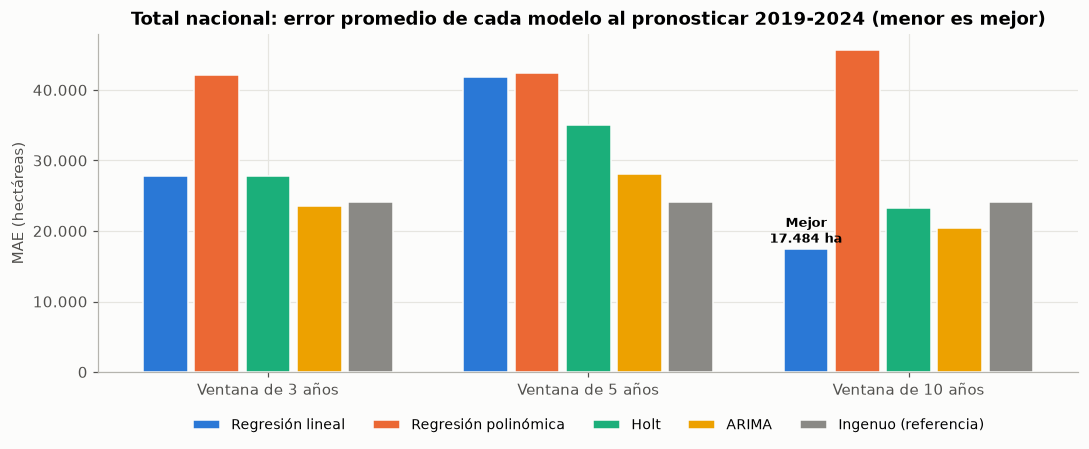

In [8]:
# Gráfico de barras: MAE por modelo, agrupado por ventana
fig, ax = plt.subplots(figsize=(10, 4.2))
orden = list(MODELOS)
ancho = 0.16
x = np.arange(len(VENTANAS))
for i, modelo in enumerate(orden):
    valores = [errores_nacional.query("modelo == @modelo and ventana == @v")["MAE"].iloc[0] for v in VENTANAS]
    barras = ax.bar(x + (i - 2) * ancho, valores, width=ancho - 0.02, color=COLORES[modelo],
                    label=MODELOS_NOMBRE[modelo], edgecolor="#fcfcfb", linewidth=1)
    for b, v, vent in zip(barras, valores, VENTANAS):
        if modelo == MODELO_NAC and vent == VENTANA_NAC:
            ax.annotate(f"Mejor\n{formato_miles(v)} ha", (b.get_x() + b.get_width() / 2, v),
                        textcoords="offset points", xytext=(0, 4), ha="center", fontsize=8.5, fontweight="bold")
ax.set_xticks(x, [f"Ventana de {v} años" for v in VENTANAS])
ax.yaxis.set_major_formatter(EJE_MILES)
ax.set_ylabel("MAE (hectáreas)")
ax.set_title("Total nacional: error promedio de cada modelo al pronosticar 2019-2024 (menor es mejor)")
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.1), fontsize=9)
plt.tight_layout()
plt.savefig(CARPETA_RESULTADOS / "02_comparacion_modelos_nacional.png")
plt.show()

### 5.2 ¿Cómo se ven esos pronósticos de prueba?

Para la ventana ganadora, comparamos lo que cada modelo **habría pronosticado** cada año contra lo que **realmente pasó** (línea negra).

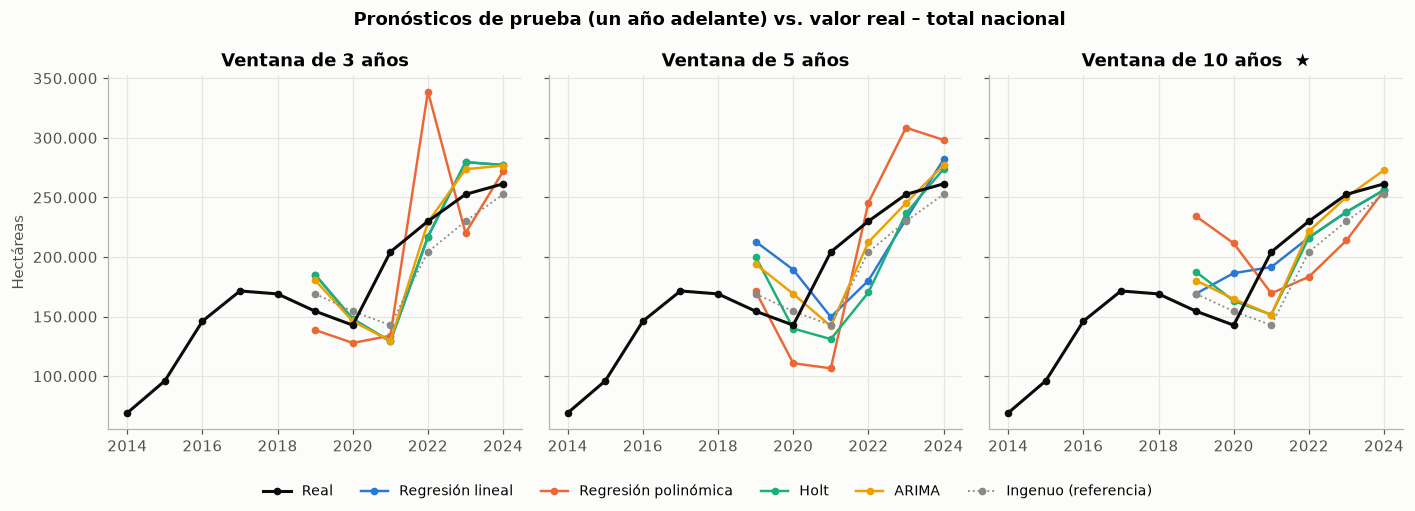

In [9]:
fig, axes = plt.subplots(1, len(VENTANAS), figsize=(13, 4.6), sharey=True)
for ax, ventana in zip(axes, VENTANAS):
    ax.plot(total_nacional.loc[2014:2024].index, total_nacional.loc[2014:2024].values,
            color=COLORES["real"], marker="o", markersize=4, label="Real", zorder=5)
    for modelo in MODELOS:
        d = bt_nacional.query("modelo == @modelo and ventana == @ventana")
        ax.plot(d["anio"], d["pronostico"], color=COLORES[modelo], marker="o", markersize=4,
                linewidth=1.6 if modelo != "ingenuo" else 1.2, linestyle="-" if modelo != "ingenuo" else ":",
                label=MODELOS_NOMBRE[modelo])
    ax.set_title(f"Ventana de {ventana} años" + ("  ★" if ventana == VENTANA_NAC else ""))
    ax.yaxis.set_major_formatter(EJE_MILES)
    ax.set_xticks(range(2014, 2025, 2))
axes[0].set_ylabel("Hectáreas")
manijas, etiquetas = axes[0].get_legend_handles_labels()
fig.legend(manijas, etiquetas, ncol=6, loc="lower center", fontsize=9)
fig.suptitle("Pronósticos de prueba (un año adelante) vs. valor real – total nacional", fontweight="bold")
plt.tight_layout(rect=(0, 0.07, 1, 1))
plt.savefig(CARPETA_RESULTADOS / "03_backtest_nacional.png", bbox_inches="tight")
plt.show()

### 5.3 Pronóstico nacional 2025

Ahora sí usamos **los datos hasta 2024** para pronosticar 2025 con cada modelo y ventana.
El **rango orientativo** es el pronóstico ± el error promedio (MAE) que ese modelo tuvo en la prueba:
si en el pasado se equivocó en promedio 20.000 ha, es razonable esperar un margen parecido.

In [10]:
filas = []
for ventana in VENTANAS:
    for modelo in MODELOS:
        pron = pronosticar(total_nacional, ANIO_PRONOSTICO, modelo, ventana)
        mae = errores_nacional.query("modelo == @modelo and ventana == @ventana")["MAE"].iloc[0]
        filas.append({"modelo": modelo, "ventana": ventana, "pronostico_2025": pron, "MAE": mae})
pron_nac_todos = pd.DataFrame(filas)
pron_nac_todos["Modelo"] = pron_nac_todos["modelo"].map(MODELOS_NOMBRE)

elegido = pron_nac_todos.query("modelo == @MODELO_NAC and ventana == @VENTANA_NAC").iloc[0]
PRON_NAC_2025, MAE_NAC = elegido["pronostico_2025"], elegido["MAE"]
real_2024 = total_nacional.loc[2024]

tabla_nacional = pd.DataFrame([{
    "Nivel": "Total nacional",
    "Hectáreas 2023 (real)": total_nacional.loc[2023],
    "Hectáreas 2024 (real)": real_2024,
    "Pronóstico 2025": PRON_NAC_2025,
    "Rango orientativo (mín.)": max(0, PRON_NAC_2025 - MAE_NAC),
    "Rango orientativo (máx.)": PRON_NAC_2025 + MAE_NAC,
    "Variación vs 2024": PRON_NAC_2025 / real_2024 - 1,
    "Modelo usado": f"{MODELOS_NOMBRE[MODELO_NAC]} ({VENTANA_NAC} años)",
}]).set_index("Nivel")
tabla_nacional.to_csv(CARPETA_RESULTADOS / "pronostico_nacional_2025.csv")

print("📌 PRONÓSTICO NACIONAL 2025")
fmt = {c: formato_miles for c in tabla_nacional.columns if "ectáreas" in c or "Pronóstico" in c or "Rango" in c}
fmt["Variación vs 2024"] = "{:+.1%}"
tabla_nacional.style.format(fmt)

📌 PRONÓSTICO NACIONAL 2025


,Hectáreas 2023 (real),Hectáreas 2024 (real),Pronóstico 2025,Rango orientativo (mín.),Rango orientativo (máx.),Variación vs 2024,Modelo usado
Nivel,,,,,,,
Total nacional,252.572,261.386,270.138,252.654,287.622,+3.3%,Regresión lineal (10 años)


In [11]:
# Todos los modelos lado a lado (para ver qué tanto difieren entre sí)
comparativo = pron_nac_todos.pivot(index="Modelo", columns="ventana", values="pronostico_2025")
comparativo = comparativo.reindex([MODELOS_NOMBRE[m] for m in MODELOS])
comparativo.columns = [f"Ventana {v} años" for v in comparativo.columns]
print("Pronóstico 2025 de cada combinación (hectáreas). La elegida es la de menor error en la prueba:")
comparativo.style.format(formato_miles)

Pronóstico 2025 de cada combinación (hectáreas). La elegida es la de menor error en la prueba:


,Ventana 3 años,Ventana 5 años,Ventana 10 años
Modelo,,,
Regresión lineal,279.354,303.861,270.138
Regresión polinómica,256.471,249.589,289.460
Holt,279.354,291.044,270.138
ARIMA,277.065,291.037,279.753
Ingenuo (referencia),261.386,261.386,261.386


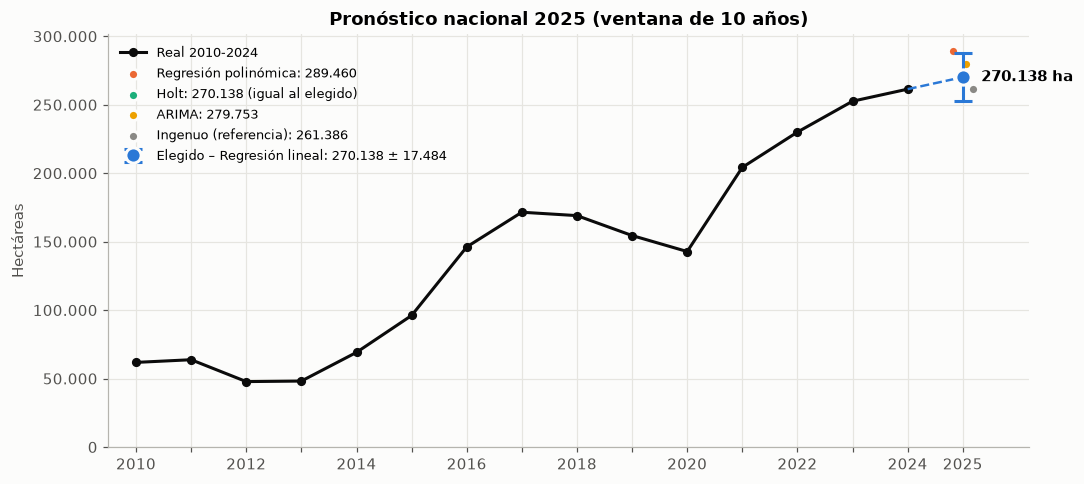

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.5))
hist = total_nacional.loc[2010:2024]
ax.plot(hist.index, hist.values, color=COLORES["real"], marker="o", markersize=5, label="Real 2010-2024")

# Pronósticos 2025 de todos los modelos con la ventana ganadora (puntos pequeños)
for i, modelo in enumerate([m for m in MODELOS if m != MODELO_NAC]):
    p = pron_nac_todos.query("modelo == @modelo and ventana == @VENTANA_NAC")["pronostico_2025"].iloc[0]
    ax.scatter(2025 + 0.12 * (i - 1.5), p, color=COLORES[modelo], s=45, zorder=4,
               edgecolor="#fcfcfb", linewidth=2,
               label=f"{MODELOS_NOMBRE[modelo]}: {formato_miles(p)}" + (" (igual al elegido)" if abs(p - PRON_NAC_2025) < 5 else ""))

# Pronóstico elegido con su rango
ax.errorbar(2025, PRON_NAC_2025, yerr=MAE_NAC, fmt="o", color=COLORES[MODELO_NAC], markersize=10,
            capsize=6, elinewidth=2, zorder=6, markeredgecolor="#fcfcfb", markeredgewidth=2,
            label=f"Elegido – {MODELOS_NOMBRE[MODELO_NAC]}: {formato_miles(PRON_NAC_2025)} ± {formato_miles(MAE_NAC)}")
ax.plot([2024, 2025], [real_2024, PRON_NAC_2025], color=COLORES[MODELO_NAC], linestyle="--", linewidth=1.6)
ax.annotate(f"{formato_miles(PRON_NAC_2025)} ha", (2025, PRON_NAC_2025), textcoords="offset points",
            xytext=(12, 0), va="center", fontweight="bold")
ax.yaxis.set_major_formatter(EJE_MILES)
ax.set_ylim(0, None)
ax.set_xlim(2009.5, 2026.2)
ax.set_xticks(list(range(2010, 2026, 1)), [str(a) if a % 2 == 0 or a == 2025 else "" for a in range(2010, 2026)])
ax.set_ylabel("Hectáreas")
ax.set_title(f"Pronóstico nacional 2025 (ventana de {VENTANA_NAC} años)")
ax.legend(loc="upper left", fontsize=8.5)
plt.tight_layout()
plt.savefig(CARPETA_RESULTADOS / "04_pronostico_nacional_2025.png")
plt.show()

In [13]:
# Explicación automática del resultado nacional, en lenguaje sencillo
mae_por_ventana = candidatos.groupby("ventana")["MAE"].min()
print(f"""¿Por qué {MODELOS_NOMBRE[MODELO_NAC]} con {VENTANA_NAC} años?
 • En la prueba 2019-2024 se equivocó en promedio {formato_miles(MAE_NAC)} ha por año, el menor error de las
   {len(candidatos)} combinaciones evaluadas (≈{MAE_NAC / total_nacional.loc[ANIOS_PRUEBA].mean():.0%} del total anual).
 • Le gana a la referencia ingenua ("igual al año anterior"), que se equivocó {formato_miles(mae_ingenuo)} ha:
   {'sí aporta información' if MAE_NAC < mae_ingenuo else 'OJO: no le gana, el pronóstico debe tomarse con cautela'}.
 • Mejor error por ventana: """ + ", ".join(f"{v} años = {formato_miles(e)} ha" for v, e in mae_por_ventana.items()))

¿Por qué Regresión lineal con 10 años?
 • En la prueba 2019-2024 se equivocó en promedio 17.484 ha por año, el menor error de las
   12 combinaciones evaluadas (≈8% del total anual).
 • Le gana a la referencia ingenua ("igual al año anterior"), que se equivocó 24.139 ha:
   sí aporta información.
 • Mejor error por ventana: 3 años = 23.509 ha, 5 años = 28.116 ha, 10 años = 17.484 ha


## 6. Pronóstico por municipio

### 6.1 ¿Qué municipios analizamos?

De los municipios en el archivo, muchos llevan años **sin coca detectada**. Pronosticar esos municipios con modelos
de tendencia no tiene sentido (el resultado sería 0). Por eso:

- **Analizamos con los 5 modelos** a los municipios que tuvieron coca en **al menos uno de los últimos 3 años (2022-2024)**.
- A los demás les asignamos **0 ha** en 2025 (sin coca reciente) y lo marcamos en la tabla final.

⏱️ Esta celda tarda 1-2 minutos: son miles de ajustes de modelos (municipios × modelos × ventanas × años de prueba).

In [14]:
activos = panel.columns[(panel.loc[2022:2024] > 0).any()]
inactivos = panel.columns.difference(activos)
print(f"Municipios con coca en 2022-2024: {len(activos)} | sin coca reciente: {len(inactivos)}")
print(f"Los activos concentran el {panel.loc[2024, activos].sum() / total_nacional.loc[2024]:.0%} de la coca de 2024")

resultados_mpio = []
for cod in activos:
    r = backtest(panel[cod])
    r["cod_municipio"] = cod
    resultados_mpio.append(r)
bt_municipal = pd.concat(resultados_mpio, ignore_index=True)
print(f"✅ {len(bt_municipal):,} pronósticos de prueba calculados")

Municipios con coca en 2022-2024: 188 | sin coca reciente: 131
Los activos concentran el 100% de la coca de 2024


✅ 16,920 pronósticos de prueba calculados


### 6.2 ¿Qué modelo funciona mejor para los municipios?

Sumamos el error absoluto de **todos los municipios** para cada combinación. Así elegimos **una regla general**
(un modelo + una ventana) para todos: es más confiable que elegir un modelo distinto para cada municipio con sólo
6 años de prueba, porque con tan pocos datos el "ganador" de cada municipio puede serlo por pura suerte.

In [15]:
bt_municipal["error_abs"] = bt_municipal["error"].abs()
errores_mpio = (bt_municipal.groupby(["modelo", "ventana"])
                .agg(MAE=("error_abs", "mean"), RMSE=("error", lambda e: np.sqrt((e ** 2).mean())))
                .reset_index())
errores_mpio["Modelo"] = errores_mpio["modelo"].map(MODELOS_NOMBRE)

cand_mpio = errores_mpio[errores_mpio["modelo"] != "ingenuo"]
mejor_mpio = cand_mpio.sort_values(["MAE", "RMSE"]).iloc[0]
MODELO_MPIO, VENTANA_MPIO = mejor_mpio["modelo"], int(mejor_mpio["ventana"])
mae_ingenuo_mpio = errores_mpio.query("modelo == 'ingenuo'")["MAE"].iloc[0]

t1 = errores_mpio.pivot(index="Modelo", columns="ventana", values="MAE").reindex([MODELOS_NOMBRE[m] for m in MODELOS])
t1.columns = [f"MAE {v} años" for v in t1.columns]
t2 = errores_mpio.pivot(index="Modelo", columns="ventana", values="RMSE").reindex([MODELOS_NOMBRE[m] for m in MODELOS])
t2.columns = [f"RMSE {v} años" for v in t2.columns]
tabla_errores_mpio = pd.concat([t1, t2], axis=1)
tabla_errores_mpio.to_csv(CARPETA_RESULTADOS / "errores_modelos_municipal.csv")

print(f"🏆 Mejor regla municipal: {MODELOS_NOMBRE[MODELO_MPIO]} con ventana de {VENTANA_MPIO} años")
print(f"   Error promedio por municipio y año: {formato_miles(mejor_mpio['MAE'])} ha "
      f"(referencia ingenua: {formato_miles(mae_ingenuo_mpio)} ha)\n")
if mejor_mpio["MAE"] > mae_ingenuo_mpio:
    print("⚠️ Ojo: a nivel municipal la referencia ingenua (\"2025 = 2024\") tuvo un error algo MENOR que los 4 modelos.\n"
          "   Es decir, en municipios los cambios de un año a otro son tan erráticos que prolongar la tendencia no mejora\n"
          f"   a simplemente repetir el último dato. Usamos {MODELOS_NOMBRE[MODELO_MPIO]} porque es el mejor de los 4 modelos\n"
          "   pedidos y su RMSE es similar al ingenuo (tiene pocos fallos grandes); la columna 'Ha 2024' de la tabla final\n"
          "   sirve como escenario alternativo \"sin cambio\".\n")
print("Error promedio por municipio-año (hectáreas):")
tabla_errores_mpio.style.format(formato_miles).highlight_min(axis=None, subset=list(t1.columns), color="#b7d3f6")

🏆 Mejor regla municipal: ARIMA con ventana de 10 años
   Error promedio por municipio y año: 225 ha (referencia ingenua: 210 ha)

⚠️ Ojo: a nivel municipal la referencia ingenua ("2025 = 2024") tuvo un error algo MENOR que los 4 modelos.
   Es decir, en municipios los cambios de un año a otro son tan erráticos que prolongar la tendencia no mejora
   a simplemente repetir el último dato. Usamos ARIMA porque es el mejor de los 4 modelos
   pedidos y su RMSE es similar al ingenuo (tiene pocos fallos grandes); la columna 'Ha 2024' de la tabla final
   sirve como escenario alternativo "sin cambio".

Error promedio por municipio-año (hectáreas):


,MAE 3 años,MAE 5 años,MAE 10 años,RMSE 3 años,RMSE 5 años,RMSE 10 años
Modelo,,,,,,
Regresión lineal,274,298,271,733,833,795
Regresión polinómica,447,365,354,1.188,922,1.023
Holt,274,294,265,733,781,799
ARIMA,264,242,225,704,689,612
Ingenuo (referencia),210,210,210,613,613,613


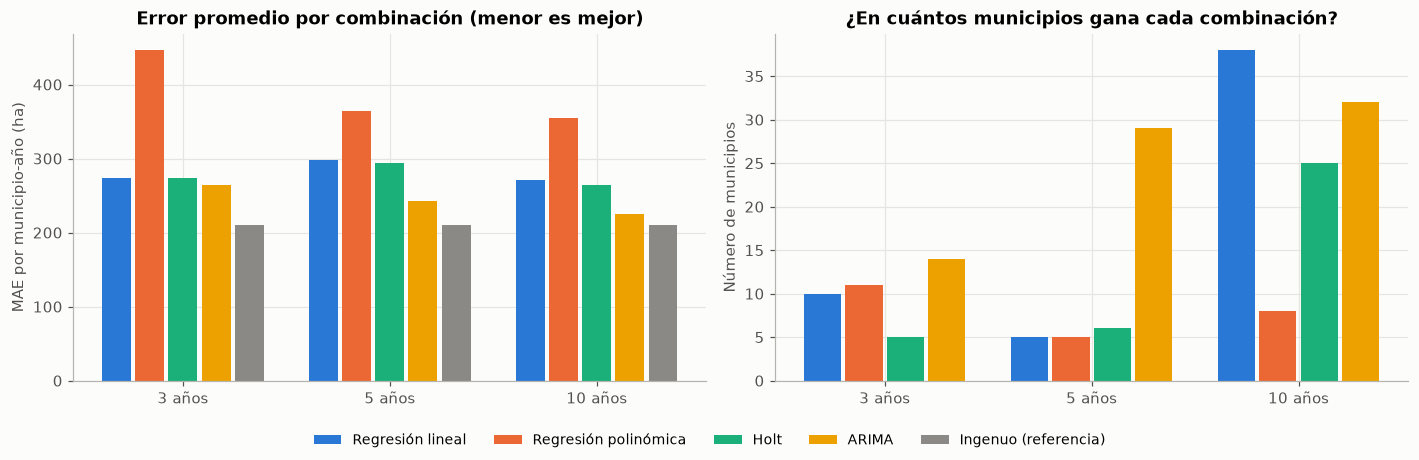

In [16]:
# ¿Qué modelo gana en cada municipio si se evaluara uno por uno? (sólo informativo)
mae_mpio_combo = bt_municipal.groupby(["cod_municipio", "modelo", "ventana"])["error_abs"].mean().reset_index()
ganador_mpio = (mae_mpio_combo[mae_mpio_combo["modelo"] != "ingenuo"]
                .sort_values("error_abs").groupby("cod_municipio").head(1))
conteo = ganador_mpio.groupby(["modelo", "ventana"]).size().unstack(fill_value=0).reindex(
    [m for m in MODELOS if m != "ingenuo"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
# Izquierda: error total por combinación
ax = axes[0]
x = np.arange(len(VENTANAS))
for i, modelo in enumerate(MODELOS):
    vals = [errores_mpio.query("modelo == @modelo and ventana == @v")["MAE"].iloc[0] for v in VENTANAS]
    ax.bar(x + (i - 2) * 0.16, vals, width=0.14, color=COLORES[modelo], label=MODELOS_NOMBRE[modelo])
ax.set_xticks(x, [f"{v} años" for v in VENTANAS])
ax.set_ylabel("MAE por municipio-año (ha)")
ax.set_title("Error promedio por combinación (menor es mejor)")
ax.yaxis.set_major_formatter(EJE_MILES)
# Derecha: en cuántos municipios gana cada combinación
ax = axes[1]
for i, modelo in enumerate(conteo.index):
    ax.bar(x + (i - 1.5) * 0.2, conteo.loc[modelo, VENTANAS].values, width=0.18,
           color=COLORES[modelo], label=MODELOS_NOMBRE[modelo])
ax.set_xticks(x, [f"{v} años" for v in VENTANAS])
ax.set_ylabel("Número de municipios")
ax.set_title("¿En cuántos municipios gana cada combinación?")
manijas, etiquetas = axes[0].get_legend_handles_labels()
fig.legend(manijas, etiquetas, ncol=5, loc="lower center", fontsize=9)
plt.tight_layout(rect=(0, 0.07, 1, 1))
plt.savefig(CARPETA_RESULTADOS / "05_comparacion_modelos_municipal.png")
plt.show()

### 6.3 Pronósticos municipales 2025

Aplicamos la regla ganadora a cada municipio con los datos hasta 2024.
El **rango orientativo** usa el error que tuvo esa misma regla **en ese municipio** durante la prueba.

In [17]:
mae_regla = (bt_municipal.query("modelo == @MODELO_MPIO and ventana == @VENTANA_MPIO")
             .groupby("cod_municipio")["error_abs"].mean())

filas = []
for cod in panel.columns:
    es_activo = cod in activos
    pron = pronosticar(panel[cod], ANIO_PRONOSTICO, MODELO_MPIO, VENTANA_MPIO) if es_activo else 0.0
    mae = mae_regla.get(cod, 0.0)
    filas.append({
        "cod_municipio": cod,
        "Municipio": dim_municipio.loc[cod, "municipio"],
        "Departamento": dim_municipio.loc[cod, "departamento"],
        "Ha 2023": panel.loc[2023, cod],
        "Ha 2024": panel.loc[2024, cod],
        "Pronóstico 2025": pron,
        "Rango mín.": max(0.0, pron - mae),
        "Rango máx.": pron + mae,
        "Nota": "" if es_activo else "Sin coca 2022-2024 → 0",
    })
pron_municipal = pd.DataFrame(filas).sort_values("Pronóstico 2025", ascending=False).reset_index(drop=True)
pron_municipal["Variación vs 2024"] = np.where(pron_municipal["Ha 2024"] > 0,
                                               pron_municipal["Pronóstico 2025"] / pron_municipal["Ha 2024"] - 1, np.nan)
pron_municipal["% del total 2025"] = pron_municipal["Pronóstico 2025"] / pron_municipal["Pronóstico 2025"].sum()
pron_municipal["% acumulado"] = pron_municipal["% del total 2025"].cumsum()
pron_municipal.index = pron_municipal.index + 1
pron_municipal.to_csv(CARPETA_RESULTADOS / "pronostico_municipal_2025.csv", index_label="ranking")

top = pron_municipal.head(TOP_MUNICIPIOS)
print(f"📌 TOP {TOP_MUNICIPIOS} MUNICIPIOS – pronóstico 2025 con {MODELOS_NOMBRE[MODELO_MPIO]} ({VENTANA_MPIO} años)")
print(f"   Estos {TOP_MUNICIPIOS} municipios concentran el {top['% del total 2025'].sum():.0%} del total pronosticado.")
print(f"   La tabla completa ({len(pron_municipal)} municipios) está en resultados/pronostico_municipal_2025.csv\n")
columnas = ["Municipio", "Departamento", "Ha 2023", "Ha 2024", "Pronóstico 2025", "Rango mín.", "Rango máx.",
            "Variación vs 2024", "% acumulado"]
fmt = {c: formato_miles for c in ["Ha 2023", "Ha 2024", "Pronóstico 2025", "Rango mín.", "Rango máx."]}
fmt.update({"Variación vs 2024": "{:+.0%}", "% acumulado": "{:.0%}"})
top[columnas].style.format(fmt, na_rep="–")

📌 TOP 20 MUNICIPIOS – pronóstico 2025 con ARIMA (10 años)
   Estos 20 municipios concentran el 64% del total pronosticado.
   La tabla completa (319 municipios) está en resultados/pronostico_municipal_2025.csv



,Municipio,Departamento,Ha 2023,Ha 2024,Pronóstico 2025,Rango mín.,Rango máx.,Variación vs 2024,% acumulado
1,Tumaco,Nariño,23.000,31.300,35.672,31.097,40.246,+14%,13%
2,Tibú,Norte De Santander,23.030,25.911,28.304,26.501,30.106,+9%,22%
3,El Tambo,Cauca,9.392,10.326,11.307,10.808,11.805,+9%,26%
4,El Charco,Nariño,9.258,8.800,10.846,9.427,12.265,+23%,30%
5,Puerto Asís,Putumayo,11.726,9.893,10.320,8.400,12.240,+4%,34%
6,Valle Del Guamuez,Putumayo,9.193,8.968,9.289,8.472,10.106,+4%,37%
7,El Tarra,Norte De Santander,6.864,7.665,8.286,7.988,8.583,+8%,40%
8,Orito,Putumayo,8.732,7.669,7.368,5.682,9.055,-4%,43%
9,San Miguel,Putumayo,6.723,6.411,6.863,6.195,7.532,+7%,45%
10,Roberto Payán,Nariño,5.408,5.950,6.395,6.007,6.784,+7%,47%


In [18]:
# Resumen por departamento (útil si la tabla municipal es muy extensa)
por_depto = (pron_municipal.groupby("Departamento")[["Ha 2024", "Pronóstico 2025"]].sum()
             .sort_values("Pronóstico 2025", ascending=False))
por_depto = por_depto[por_depto["Pronóstico 2025"] > 0]
por_depto["Variación vs 2024"] = por_depto["Pronóstico 2025"] / por_depto["Ha 2024"] - 1
por_depto.to_csv(CARPETA_RESULTADOS / "pronostico_departamental_2025.csv")
print("Pronóstico 2025 agregado por departamento (suma de sus municipios):")
por_depto.style.format({"Ha 2024": formato_miles, "Pronóstico 2025": formato_miles, "Variación vs 2024": "{:+.0%}"})

Pronóstico 2025 agregado por departamento (suma de sus municipios):


,Ha 2024,Pronóstico 2025,Variación vs 2024
Departamento,,,
Nariño,74.548,84.071,+13%
Norte De Santander,48.739,52.773,+8%
Putumayo,44.473,45.937,+3%
Cauca,36.876,41.314,+12%
Antioquia,17.163,19.064,+11%
Bolívar,10.440,11.394,+9%
Córdoba,6.585,7.634,+16%
Chocó,6.535,7.218,+10%
Guaviare,5.021,4.976,-1%


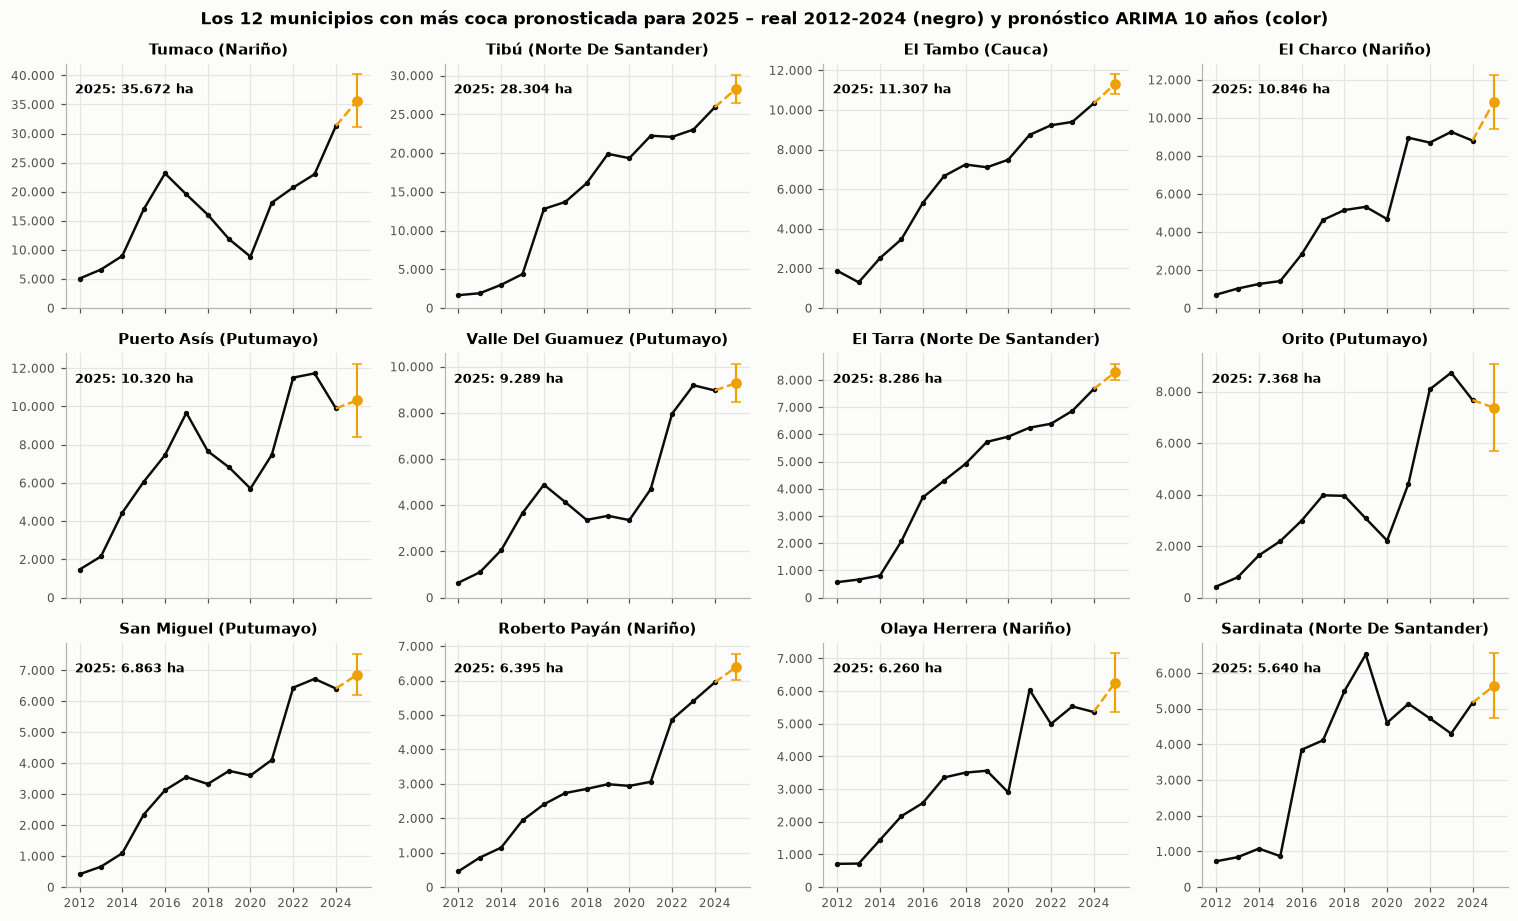

In [19]:
# Series de los 12 municipios principales con su pronóstico 2025
top12 = pron_municipal.head(12)
fig, axes = plt.subplots(3, 4, figsize=(14, 8.5), sharex=True)
for ax, (_, fila) in zip(axes.flat, top12.iterrows()):
    serie = panel[fila["cod_municipio"]].loc[2012:2024]
    ax.plot(serie.index, serie.values, color=COLORES["real"], linewidth=1.6, marker="o", markersize=2.5)
    ax.plot([2024, 2025], [serie.loc[2024], fila["Pronóstico 2025"]], color=COLORES[MODELO_MPIO],
            linestyle="--", linewidth=1.6)
    ax.errorbar(2025, fila["Pronóstico 2025"],
                yerr=[[fila["Pronóstico 2025"] - fila["Rango mín."]], [fila["Rango máx."] - fila["Pronóstico 2025"]]],
                fmt="o", color=COLORES[MODELO_MPIO], markersize=6, capsize=3, elinewidth=1.4)
    ax.set_title(f"{fila['Municipio']} ({fila['Departamento']})", fontsize=9.5)
    ax.yaxis.set_major_formatter(EJE_MILES)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, None)
    ax.text(0.03, 0.92, f"2025: {formato_miles(fila['Pronóstico 2025'])} ha", transform=ax.transAxes,
            fontsize=8.5, fontweight="bold", va="top")
fig.suptitle(f"Los 12 municipios con más coca pronosticada para 2025 – real 2012-2024 (negro) y "
             f"pronóstico {MODELOS_NOMBRE[MODELO_MPIO]} {VENTANA_MPIO} años (color)", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig(CARPETA_RESULTADOS / "06_top12_municipios.png")
plt.show()

### 6.4 Coherencia entre el total nacional y la suma de municipios

Si sumamos los pronósticos de todos los municipios deberíamos obtener algo cercano al pronóstico nacional.
No tienen por qué coincidir exactamente: el total nacional se modela como una sola serie (más estable) y cada
municipio por separado (más ruidoso). **Para el total del país recomendamos usar el pronóstico nacional directo.**

In [20]:
suma_mpios = pron_municipal["Pronóstico 2025"].sum()
print(f"Pronóstico nacional directo ({MODELOS_NOMBRE[MODELO_NAC]}, {VENTANA_NAC} años): {formato_miles(PRON_NAC_2025)} ha")
print(f"Suma de pronósticos municipales ({MODELOS_NOMBRE[MODELO_MPIO]}, {VENTANA_MPIO} años): {formato_miles(suma_mpios)} ha")
print(f"Diferencia: {(suma_mpios / PRON_NAC_2025 - 1):+.1%}")

# Exportar todo a un Excel con una hoja por tabla
with pd.ExcelWriter(CARPETA_RESULTADOS / "pronosticos_coca_2025.xlsx") as xls:
    tabla_nacional.to_excel(xls, sheet_name="Total nacional")
    pron_municipal.to_excel(xls, sheet_name="Municipios", index_label="ranking")
    por_depto.to_excel(xls, sheet_name="Departamentos")
    tabla_errores_nac.to_excel(xls, sheet_name="Errores nacional")
    tabla_errores_mpio.to_excel(xls, sheet_name="Errores municipal")
print("\n✅ Resultados guardados en la carpeta 'resultados/' (CSV, Excel y gráficos PNG)")

Pronóstico nacional directo (Regresión lineal, 10 años): 270.138 ha
Suma de pronósticos municipales (ARIMA, 10 años): 285.010 ha
Diferencia: +5.5%

✅ Resultados guardados en la carpeta 'resultados/' (CSV, Excel y gráficos PNG)


## 7. Limitaciones: ¿qué tan confiables son estos pronósticos?

1. **Pocos datos.** Hay un dato por año: 24 en total, y sólo 3, 5 o 10 dentro de cada ventana. Con tan pocos puntos,
   cualquier modelo es frágil y la diferencia entre modelos puede cambiar si se añade un año más.
2. **La serie cambia de dirección.** La coca cayó 2001-2012, se disparó 2013-2017, bajó en 2019-2020 y volvió a subir.
   Estos giros responden a **decisiones de política** (fumigación, acuerdos de paz, erradicación, programas de sustitución),
   precios y orden público, que **ningún modelo de tendencia puede anticipar**. Los modelos suponen que "lo reciente continúa".
3. **Municipios muy volátiles.** Un municipio puede pasar de 500 a 3.000 ha en un año o desaparecer. A nivel municipal
   los errores relativos son mucho mayores que en el total nacional; úsense los pronósticos municipales como
   **orden de magnitud y ranking**, no como cifra exacta.
4. **Municipios sin coca reciente → 0.** Si la coca aparece en un municipio nuevo en 2025, este método no lo detecta.
5. **El rango orientativo no es un intervalo de confianza formal.** Es el error promedio histórico; el valor real podría
   quedar fuera de él, sobre todo si hay un cambio de política.
6. **Calidad del dato 2020.** El formato distinto de esa columna sugiere que se cargó por otra vía; ya se corrigió aquí,
   pero conviene **corregir también el notebook de limpieza** (`parsear_hectareas`) para que la bodega de datos
   (`FactCultivos`) no tenga 2020 subestimado.
7. **Definición de "producción".** Los datos son **hectáreas sembradas detectadas** (área), no toneladas de hoja o de
   cocaína. Un pronóstico de producción requeriría además rendimientos por región.

In [21]:
# Resumen final en pocas líneas
print("=" * 78)
print("RESUMEN")
print("=" * 78)
print(f"Total nacional 2024 (real):       {formato_miles(total_nacional.loc[2024])} ha")
print(f"Total nacional 2025 (pronóstico): {formato_miles(PRON_NAC_2025)} ha  "
      f"[{formato_miles(max(0, PRON_NAC_2025 - MAE_NAC))} – {formato_miles(PRON_NAC_2025 + MAE_NAC)}]  "
      f"({PRON_NAC_2025 / total_nacional.loc[2024] - 1:+.1%})")
print(f"Modelo nacional:   {MODELOS_NOMBRE[MODELO_NAC]}, ventana {VENTANA_NAC} años (MAE {formato_miles(MAE_NAC)} ha)")
print(f"Modelo municipal:  {MODELOS_NOMBRE[MODELO_MPIO]}, ventana {VENTANA_MPIO} años "
      f"(MAE {formato_miles(mejor_mpio['MAE'])} ha por municipio-año)")
print(f"Top 5 municipios 2025: " + ", ".join(
    f"{r['Municipio']} ({formato_miles(r['Pronóstico 2025'])})" for _, r in pron_municipal.head(5).iterrows()))

RESUMEN
Total nacional 2024 (real):       261.386 ha
Total nacional 2025 (pronóstico): 270.138 ha  [252.654 – 287.622]  (+3.3%)
Modelo nacional:   Regresión lineal, ventana 10 años (MAE 17.484 ha)
Modelo municipal:  ARIMA, ventana 10 años (MAE 225 ha por municipio-año)
Top 5 municipios 2025: Tumaco (35.672), Tibú (28.304), El Tambo (11.307), El Charco (10.846), Puerto Asís (10.320)


## 8. Conclusiones

*(Cifras de la ejecución con el archivo del 31/08/2026; si cambian los datos, las celdas de arriba se recalculan.)*

**Total nacional → Regresión lineal con ventana de 10 años: ≈270.100 ha en 2025 (+3,3% frente a 2024),
rango orientativo 252.700 – 287.600 ha.**

- **Por qué ganó:** en la prueba 2019-2024 se equivocó en promedio ≈17.500 ha por año (≈8% del total), el menor
  error de las 12 combinaciones, y le gana a "repetir el año anterior" (≈24.100 ha).
- **Por qué 10 años y no 3 o 5:** la serie nacional tiene sube-y-baja de un año a otro. Con 3 o 5 años la recta
  "persigue" el último movimiento: tras la caída de 2019-2020 pronosticó más caída, y tras el salto de 2021 pronosticó
  más salto. Con 10 años la recta resume la tendencia de fondo (crecimiento sostenido desde 2014) y **no se deja
  llevar por un solo año atípico**.
- **Por qué no la polinómica:** fue la peor en todas las ventanas. La curva exagera la aceleración o el frenazo
  (llegó a pronosticar 338.000 ha para 2022).
- **Holt** terminó comportándose igual que la recta (con tan pocos datos, su mejor ajuste es una tendencia fija), y
  **ARIMA** quedó muy cerca (2º lugar, ≈20.500 ha de error): su pronóstico (≈279.800 ha) es un escenario alto razonable.

**Municipios → ARIMA con ventana de 10 años.** Fue el mejor de los 4 modelos (menor MAE y menor RMSE), pero
**no le ganó a la referencia ingenua**: a escala municipal los cambios anuales son muy erráticos. Por eso los
pronósticos municipales deben leerse como **ranking y orden de magnitud**; Tumaco, Tibú, El Tambo, El Charco y
Puerto Asís seguirían concentrando la mayor área. Para el país, usar el pronóstico nacional directo.